# Minimum Information Dependence modeling


Joint model for a mixed-domain data
proposed by Sei and Yano, Minimum information dependence modeling

$p(x; \theta, \nu)=\exp(\theta^{\top}h(x)-\sum_{j=1}^{d}a_{j}(x_j;\theta,\nu)-\psi(\theta,\nu))\prod_{j=1}^{d}r_{j}(x_{j};\nu)$

such that $a_{j}(x_j;\theta,\nu)$ and $\psi(\theta,\nu)$ are determined by

--mariginal condition $\int p(x;\theta,\nu)dx_{-j}=r_{j}(x_{j};\nu)$

--identifiability condition $\int \sum_{j=1}^{d} a_{j}(x_{j};\theta,\nu) p(x;\theta,\nu)dx=0$

In [2]:
!pip install palmerpenguins
!pip install networkx

In [10]:
#Import libraries

import numpy as np
import gc
import copy
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LogisticRegression
from scipy import linalg
import pandas as pd
import random
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
from concurrent.futures import ProcessPoolExecutor, as_completed
from typing import List, Tuple, Optional
import networkx as nx
import time

from google.colab import drive
import os
#Set the working directory
your_workingdir = '/content/drive/My Drive/min-info/code/'
drive.mount('/content/drive')
os.chdir(your_workingdir)
#Download mininfo.py and put it to the current directory
import mininfo_v2 as mininfo

import warnings
warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
fontsize = 15

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Quick start with the Penguin data (Mixed graphical model with three-dimensional interactions)
We use the palmerpenguins dataset from Horst, Hill and Gorman (2020).

- The dataset contains several qualitative and quantitative variables
- We use the variables of (1: continuous) Bill length, (2: continuous) Bill depth, (3: continuous) flipper length, (4: continuous) body mass, (5: discrete) sex
- We test $h(x)=\sum \theta_{ij}x_i x_j$ (two-dimensional effect)
and $h(x)=\sum \theta_{ij}x_i x_j + \sum \theta_{ijk}x_i x_j x_k$ (three-dimensional effect) after one hot encoding for sex


###References
- K. Gorman, T. Williams, W. Fraser (2014). Ecological sexual dimorphism and environmental variability within a community of Antarctic penguins (genus Pygoscelis). PLoS ONE 9(3):e90081. https://doi.org/10.1371/journal.pone.0090081

- A. Horst, A. Hill, K. Gorman (2020). palmerpenguins: Palmer Archipelago (Antarctica) penguin data. R package version 0.1.0. https://allisonhorst.github.io/palmerpenguins/. doi: 10.5281/zenodo.3960218.

In [7]:
#########################################################################
# Step 1: data preparation
# Data format: [[multivariate sample 1],[multivariate sample 2],...]
#########################################################################
from palmerpenguins import load_penguins
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

penguins = load_penguins()
penguins.head()
df = penguins.copy()
df.dropna(how='any')
processed_df=df[df["species"]=="Adelie"].drop(['species','island','year'], axis=1).dropna(how='any')
##Preprocessing
scaling_columns = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
sc = StandardScaler().fit(processed_df[scaling_columns])
## standardization
scaled_df = pd.DataFrame(sc.transform(processed_df[scaling_columns]), columns=scaling_columns, index=processed_df.index)
processed_df.update(scaled_df)
## One hot encoding
processed_df["sex"] = processed_df["sex"].map({"male": 1, "female": 0})
list_penguins = processed_df.values.tolist()
n = len(list_penguins)
d = len(list_penguins[0])

In [8]:
#########################################################################
#Step 2: construct h function to capture interaction
#########################################################################

# h to capture three-dimensional interaction
def h_penguins_all_3factor(x):
  h_list = []
  for i in range(5):
    for j in [ k for k in range(5) if (k>i)]:
       h_list.append(x[i]*x[j])
  for i in range(5):
    for j in [ k for k in range(5) if (k>i)]:
      for k in [kk for kk in range(5) if (kk>j)]:
        h_list.append(x[i]*x[j]*x[k])
  return np.array(h_list)

In [11]:
#########################################################################
#Step 3: statistical inference using minimum information dependence model
#########################################################################

# First check the sample size
print(f"Sample size: {n}")

M_iter = 10000
Burnin_RPJ = 5000
switch_SGD = True

if (n < 1001) and (switch_SGD == False):
  print("Conduct full-batch estimation")
  # Full-batch estimation feasible only for small n; serves as a baseline.
  Penguins_3factor_estimation = mininfo.min_info_Besag_fullbatch(
      X=list_penguins,
      h=h_penguins_all_3factor,
      max_iter=M_iter,
      tol=10**(-5))
  Penguins_3factor_UQ = mininfo.min_info_Besag_asymptoticCovariance_fullbatch(
      X=list_penguins,
      h=h_penguins_all_3factor,
      theta_PLE=Penguins_3factor_estimation
  )

else:
  print("Conduct mini-batch estimation")
  # Recommended two-stage mini-batch estimation:
  # Step 1) Warm start with Adam (no RPJ) to quickly reach a good basin.
  # Step 2) Switch to plain SGD + RPJ averaging to reduce variance and stabilize the final estimate.

  Penguins_3factor_estimation_pre = mininfo.min_info_Besag_SGD(
      X=list_penguins,
      h=h_penguins_all_3factor,
      use_adam=True,
      use_rpj=False,
      verbose_every=0
  )[0]
  Penguins_3factor_estimation, RPJcount_Penguins_3factor_estimation = mininfo.min_info_Besag_SGD(
      X=list_penguins,
      h=h_penguins_all_3factor,
      max_iter=M_iter,
      init=Penguins_3factor_estimation_pre,
      use_adam=False,
      use_rpj=True,
      avg_start=Burnin_RPJ
  )
  Penguins_3factor_UQ = mininfo.min_info_Besag_asymptoticCovariance_minibatch(
      X=list_penguins,
      h=h_penguins_all_3factor,
      theta_PLE=Penguins_3factor_estimation,
      RPJ_count=RPJcount_Penguins_3factor_estimation,
      num_s=None,
      num_t_per_s=100,
      num_pairs_J=1000,
      seed=None
  )

Sample size: 146
Conduct mini-batch estimation


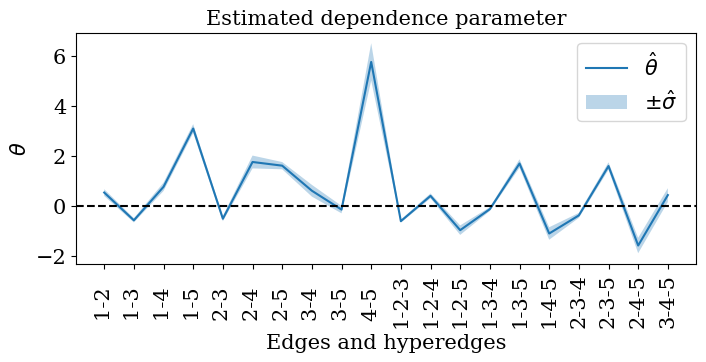

In [12]:
#########################################################################
#Step 4: Plot the estimation result
#########################################################################

#Edge labeling
edges_3factors = []
for i in range(5):
  for j in [ k for k in range(5) if (k>i)]:
      edges_3factors.append(str(i+1)+"-"+str(j+1)+"  ")
for i in range(5):
  for j in [ k for k in range(5) if (k>i)]:
    for k in [kk for kk in range(5) if (kk>j)]:
      edges_3factors.append(str(i+1)+"-"+str(j+1)+"-"+str(k+1))
k = len(edges_3factors)
#########################################################################

#Plot
fig = plt.figure(figsize=(8,3))
ax = fig.add_subplot(111)
ax.set_title("Estimated dependence parameter",fontsize=fontsize)
ax.plot(edges_3factors,Penguins_3factor_estimation,label=r"$\hat{\theta}$")
ax.axhline(y=0, color='black', linestyle='--')
ax.fill_between(edges_3factors,
                Penguins_3factor_estimation-np.sqrt(np.diag(Penguins_3factor_UQ)),
                Penguins_3factor_estimation+np.sqrt(np.diag(Penguins_3factor_UQ)),alpha=0.3,label=r"$\pm \hat{\sigma}$")
ax.tick_params(axis='x', rotation=90,labelsize=fontsize)
ax.tick_params(axis='y',labelsize=fontsize)
ax.set_xlabel("Edges and hyperedges",fontsize=fontsize)
ax.set_ylabel(r"$\theta$",fontsize=fontsize)
ax.legend(fontsize=fontsize)
plt.show()

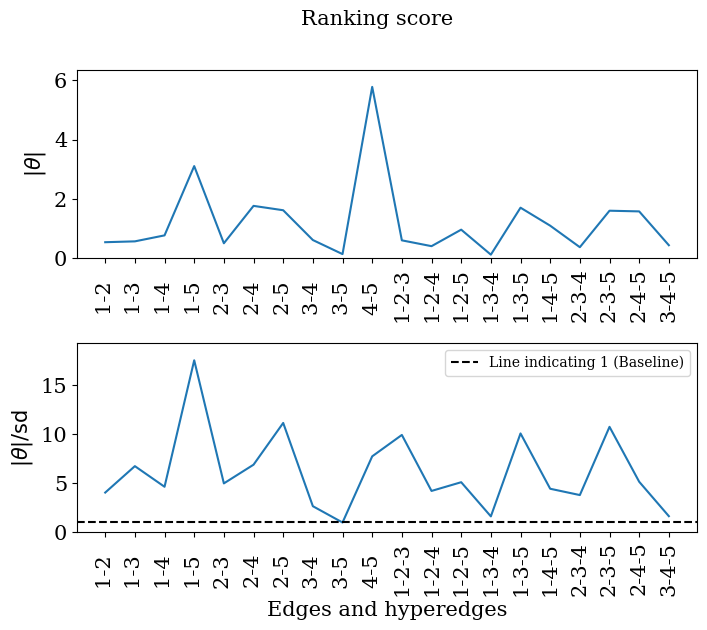

In [13]:
#########################################################################
#Step 5: Ranking the dependence
#########################################################################


#########################################################################
#There are two options for edge ranking:
#--Absolute score does not take uncertainty into account but tends to be more stable.
#--Normalized score considers estimation uncertainty but can be unstable, especially when using an SGD implementation.
#Practical guideline:
#--When using full-batch estimation, it is recommended to use the normalized score.
#--When using mini-batch estimation, it is better to use the absolute score for stability.
absolute_score   = np.abs(Penguins_3factor_estimation)
normalized_score = np.abs(np.array(Penguins_3factor_estimation))/np.sqrt(np.diag(Penguins_3factor_UQ))
#########################################################################

Max_absolute_score = np.max(absolute_score)
Max_normalized_score = np.max(normalized_score)

fig = plt.figure(figsize=(8,6))
fig.subplots_adjust(hspace=0.45)
fig.suptitle("Ranking score",fontsize=fontsize)
ax1 = fig.add_subplot(211)
ax1.set_ylabel(r"$|\theta|$",fontsize=fontsize)
ax1.plot(edges_3factors,absolute_score)
ax1.tick_params(axis='x', rotation=90,labelsize=fontsize)
ax1.tick_params(axis='y',labelsize=fontsize)
ax1.set_ylim([0,1.1*Max_absolute_score])
ax2 = fig.add_subplot(212)
ax2.set_ylabel(r"$|\theta|/\mathrm{sd}$",fontsize=fontsize)
ax2.plot(edges_3factors,normalized_score)
ax2.axhline(y=1, color='black', linestyle='--',label="Line indicating 1 (Baseline)")
ax2.tick_params(axis='x', rotation=90,labelsize=fontsize)
ax2.tick_params(axis='y',labelsize=fontsize)
ax2.set_xlabel("Edges and hyperedges",fontsize=fontsize)
ax2.set_ylim([0,1.1*Max_normalized_score])
ax2.legend()

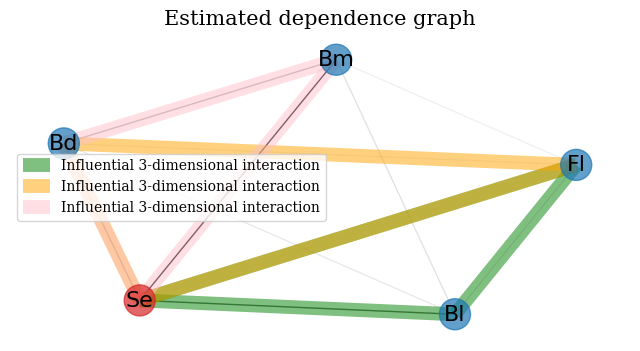

In [16]:
#########################################################################
#Step 5: Create the graph based on estimated dependence
#########################################################################

#Edge ranking
def to_ranks_desc(x):
    order = np.argsort(-np.asarray(x))           # descending
    r = np.empty_like(order)
    r[order] = np.arange(1, len(x) + 1)          # rank starts at 1
    return r

# 1) Build the four ranking score
if switch_SGD == True:
  Switch_rankingindex = "Absolute"
else:
  Switch_rankingindex = "Normalized"
if Switch_rankingindex == "Absolute":
  rankingscore_3interaction = -absolute_score
else:
  rankingscore_3interaction = -normalized_score

# 2) Turn scores into ranks (higher score => better rank 1)
rank_3interactions = to_ranks_desc(rankingscore_3interaction)
# 3) Get base index number indicating 3-dimensional interaction
base_3factor = int(d*(d-1)/2)


#########################################################################
# 4) Create the base graph
vector = {}
variables = [u"Bl", u"Bd", u"Fl", u"Bm", u"Se"]
edge_labels = {}
for person in variables:
    vector[person] = []
for i in range(5):
  for j in range(i+1,5):
    vector[variables[i]].append(variables[j])
# 5) Create the hyper graph indicating the highest dependence values among 3-dimensional interactions
circles = []
for i in [0,1,2]:
  circle = {}
  for person in variables:
      circle[person] = []
  ind = np.argsort(rankingscore_3interaction[base_3factor:])[i]
  target_3factor=edges_3factors[base_3factor+ind]
  a = int(target_3factor[0])
  b = int(target_3factor[2])
  c = int(target_3factor[4])
  circle[variables[a-1]].append(variables[b-1])
  circle[variables[b-1]].append(variables[c-1])
  circle[variables[c-1]].append(variables[a-1])

  circles.append(circle)


# 6) Plot the graph
graph = nx.Graph(vector)
plt.figure(figsize=(8, 4))
pos = nx.spring_layout(graph)

nx.draw_networkx_nodes(graph, pos, node_size=500, alpha=0.7*np.ones(5),node_color=["tab:blue","tab:blue","tab:blue","tab:blue","tab:red"])
nx.draw_networkx_edges(graph, pos, width=1,
                       edge_cmap=plt.cm.plasma,
                       alpha=np.abs(rankingscore_3interaction)/max(np.abs(rankingscore_3interaction)))
nx.draw_networkx_labels(graph, pos, font_size=16, font_color="black")

colors=["green","orange","pink"]
for i in [0,1,2]:
  graph = nx.Graph(circles[i])
  nx.draw_networkx_edges(graph, pos, width=10,edge_color=colors[i],alpha=0.5,label="Influential 3-dimensional interaction")
plt.title("Estimated dependence graph",fontsize=fontsize)
plt.xticks([])
plt.yticks([])
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.legend()
plt.show()

# Detailed comparison between fullbatch and minibatch estimation schemes

#Example 1: continuous data in the unit interval and count data
* Marginal Beta distribution for one varible $X$ in $[0,1]$
* Marginal Poisson distribution for the other variable $Y$ in $\mathbb{N}$
* Joint structure $h$ is given by $h(X,Y)=X/(Y+1)$ with canonical parameter $\theta=10$


In [20]:
#canonical statistics
def h_cd(x):
  return np.array([x[0]*(1/(x[1]+1))])

n=1000
target_th = -10

#sampling from marginals
X = np.random.beta(a=5, b=5, size=n)
Y = np.random.poisson(lam=3.,size=n)
inputlist = [[X[N],Y[N]] for N in range(n)]
#exchange algorithm
outputlist= mininfo.min_info_mcmc(X=inputlist,h=h_cd,loop=10*n,theta=np.array(target_th),printop=True)

Step/Total : 0/10000 Acceptance rate : 0.00
Step/Total : 1000/10000 Acceptance rate : 0.89
Step/Total : 2000/10000 Acceptance rate : 0.88
Step/Total : 3000/10000 Acceptance rate : 0.87
Step/Total : 4000/10000 Acceptance rate : 0.87
Step/Total : 5000/10000 Acceptance rate : 0.87
Step/Total : 6000/10000 Acceptance rate : 0.87
Step/Total : 7000/10000 Acceptance rate : 0.87
Step/Total : 8000/10000 Acceptance rate : 0.87
Step/Total : 9000/10000 Acceptance rate : 0.87


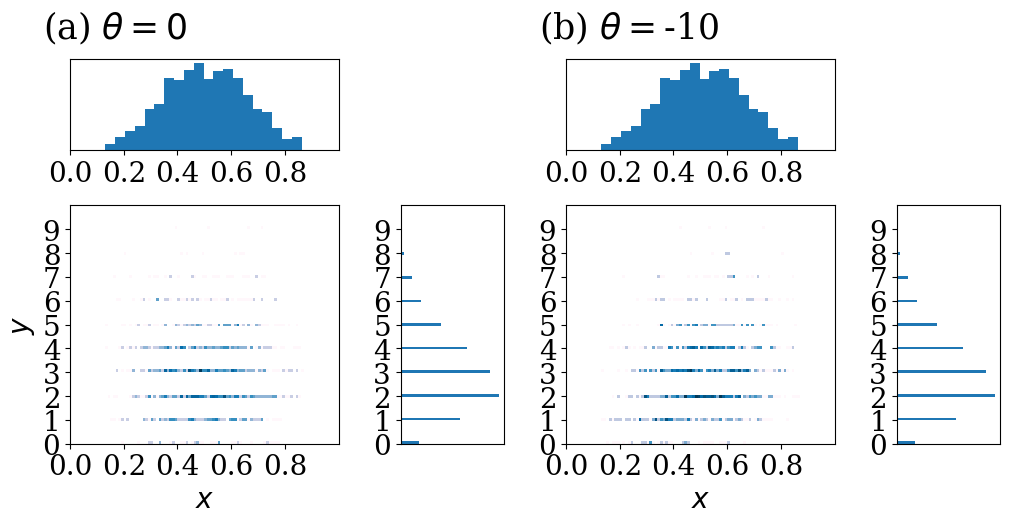

In [30]:
fig = plt.figure(figsize=(12,5))
gs = matplotlib.gridspec.GridSpec(3, 6,wspace=0.6,hspace=0.6)
ax_main_1 = plt.subplot(gs[1:3, :2])
ax_xDist_1 = plt.subplot(gs[0, :2],sharex=ax_main_1)
ax_yDist_1 = plt.subplot(gs[1:3, 2],sharey=ax_main_1)

ax_main_2 = plt.subplot(gs[1:3, 3:5])
ax_xDist_2 = plt.subplot(gs[0, 3:5],sharex=ax_main_2)
ax_yDist_2= plt.subplot(gs[1:3, 5],sharey=ax_main_2)


ax_main_1.hist2d(X,Y,bins=100,range=[[0, 1], [0, 12]],norm=matplotlib.colors.LogNorm(),cmap="PuBu")
ax_main_1.set_xlabel("$x$",fontsize=20)
ax_main_1.set_ylabel("$y$",fontsize=20)
ax_main_1.set_xlim([0,1])
ax_main_1.set_ylim([0,10])
ax_main_1.set_xticks([0.2*i for i in range(5)])
ax_main_1.set_xticklabels([round(0.2*i,2) for i in range(5)],fontsize=20)
ax_main_1.set_yticks([i for i in range(10)])
ax_main_1.set_yticklabels([round(i,2) for i in range(10)],fontsize=20)
ax_main_1.text(-0.1,17,"(a) $\\theta=0$",fontsize=25)

ax_xDist_1.hist(X,bins=20,align='mid')
ax_xDist_1.set(ylabel='')
ax_xDist_1.set_yticks([])
ax_xDist_1.set_xticklabels([round(0.2*i,2) for i in range(5)],fontsize=20)

ax_yDist_1.hist(Y,bins=100,orientation='horizontal',align='mid')
ax_yDist_1.set(xlabel='')
ax_yDist_1.set_xticks([])
ax_yDist_1.set_yticklabels([round(i,2) for i in range(10)],fontsize=20)


ax_main_2.hist2d(np.array(outputlist[-1])[:,0],np.array(outputlist[-1])[:,1],bins=100,range=[[0, 1], [0, 12]],norm=matplotlib.colors.LogNorm(),cmap="PuBu")
ax_main_2.set_xlabel("$x$",fontsize=20)
ax_main_2.set_ylabel("",fontsize=20)
ax_main_2.set_xlim([0,1])
ax_main_2.set_ylim([0,10])
ax_main_2.set_xticks([0.2*i for i in range(5)])
ax_main_2.set_xticklabels([round(0.2*i,2) for i in range(5)],fontsize=20)
ax_main_2.set_yticks([i for i in range(10)])
ax_main_2.set_yticklabels([round(i,2) for i in range(10)],fontsize=20)
ax_main_2.text(-0.1,17,"(b) $\\theta=$"+str(target_th),fontsize=25)

ax_xDist_2.hist(X,bins=20,align='mid')
ax_xDist_2.set(ylabel='')
ax_xDist_2.set_yticks([])
ax_xDist_2.set_xticklabels([round(0.2*i,2) for i in range(5)],fontsize=20)

ax_yDist_2.hist(Y,bins=100,orientation='horizontal',align='mid')
ax_yDist_2.set(xlabel='')
ax_yDist_2.set_xticks([])
ax_yDist_2.set_yticklabels([round(i,2) for i in range(10)],fontsize=20)

###Inference for theta

Conduct PLE and its uncertainty quantification

*   If $n < 1001$, we compare the fullbatch PLE with the minibatch PLE
*   If $n >= 1001$, we conduct only the minibatch PLE


In [22]:
print(f"Ground truth: "+str(np.round(target_th,3)))
if n <= 1000:
  # Full-batch: feasible only for small n; serves as a baseline.
  t0 = time.perf_counter()
  ex1_PLE_fullbatch = mininfo.min_info_Besag_fullbatch(
      X=outputlist[-1],
      h=h_cd,
      tol=1e-5,          # Convergence tolerance
      max_iter=10000,   # Upper bound on iterations; set conservatively for stability
      sparseop=False
  )
  t1 = time.perf_counter()
  print(f"Fullbatch: Get {np.round(ex1_PLE_fullbatch[0], 3)} in {t1 - t0:0.4f} seconds")

  # First approach: perform mini-batch optimization using Adam only.
  # Goal: achieve faster initial convergence due to adaptive learning rates,
  # even if the final variance of the parameters is slightly higher.
  t0 = time.perf_counter()
  ex1_PLE_Adam = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cd,
      use_adam=True,
      use_rpj=False
  )[0]
  t1 = time.perf_counter()
  print(f"Minibatch (Adam): Get {(np.round(ex1_PLE_Adam[0],3))} in {t1 - t0:0.4f} seconds")

  # Recommended practice:
  # Step 1: Use Adam (without RPJ averaging) to reach a good basin quickly.
  # Step 2: Switch to plain SGD with RPJ averaging to reduce variance and stabilize convergence.
  # This two-stage process combines fast adaptation with robust final estimates.
  t0 = time.perf_counter()
  ex1_PLE_SGD_pre = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cd,
      use_adam=True,
      use_rpj=False,
      verbose_every=0
  )[0]  # Use only the first output as the warm-start for the next stage.
  ex1_PLE_SGD, PJcount_ex1_PLE_SGD = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cd,
      init=ex1_PLE_SGD_pre,  # Warm-start from the Adam result
      use_adam=False,
      use_rpj=True,          # Apply RPJ averaging for variance reduction
      verbose_every=0
  )
  t1 = time.perf_counter()
  print(f"Minibatch (Adam+RPJ): Get {(np.round(ex1_PLE_SGD[0],3))} in {t1 - t0:0.4f} seconds")


Ground truth: -10
Fullbatch: Get -10.698 in 7.7502 seconds
Minibatch (Adam): Get -9.835 in 1.1915 seconds
Minibatch (Adam+RPJ): Get -8.075 in 2.1862 seconds


In [26]:
if n < 1001:
  # Full-batch path: feasible for small n. Provides a high-accuracy reference baseline.
  t0 = time.perf_counter()
  ex1_1_PLE_fullbatch = mininfo.min_info_Besag_fullbatch(
      X=outputlist[-1],
      h=h_cd,
      tol=1e-5,        # Practical trade-off between accuracy and runtime
      max_iter=10_000, # Conservative iteration cap for stability
      sparseop=False
  )
  ex1_1_PLE_asymptoticCov_fullbatch = mininfo.min_info_Besag_asymptoticCovariance_fullbatch(
      X=outputlist[-1],
      h=h_cd,
      theta_PLE=ex1_1_PLE_fullbatch  # Use the current full-batch estimate
  )
  t1_est = time.perf_counter()
  time_fullbatch = t1_est - t0
  print(f"Fullbatch without bootstrap: Finished in {t1_est - t0:0.4f} seconds")
  ex1_1_boot_PLE_fullbatch, ex1_1_bootm_PLE_fullbatch, ex1_1_bootcov_PLE_fullbatch = \
      mininfo.min_info_Besag_bootstrap_fullbatch(
          X=outputlist[-1],
          h=h_cd,
          tol=1e-5,
          max_iter=10_000,
          B=50,
          sparseop=False
      )
  t1 = time.perf_counter()
  time_fullbatch_total = t1 - t0
  print(f"Fullbatch with bootstrap: Finished in {t1 - t0:0.4f} seconds")

  # Mini-batch with Adam only:
  # Rationale: fast initial progress via adaptive steps; acceptable if final variance is slightly higher.
  t0_Adam = time.perf_counter()
  ex1_1_PLE_Adam = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cd,
      use_adam=True,
      use_rpj=False
  )[0]
  ex1_1_PLE_Adam_asymptoticCov = mininfo.min_info_Besag_asymptoticCovariance_minibatch(
      X=outputlist[-1],
      h=h_cd,
      theta_PLE=ex1_1_PLE_Adam,
      RPJ_count=np.inf,
      num_s=None,
      num_t_per_s=10,
      num_pairs_J=100,
      seed=None
  )
  t1_est_Adam = time.perf_counter()
  time_Adam = t1_est_Adam - t0_Adam
  print(f"Minibatch (Adam) without bootstrap: Finished in {time_Adam:0.4f} seconds")
  ex1_1_boot_PLE_Adam, ex1_1_bootm_PLE_Adam,ex1_1_bootcov_PLE_Adam = \
      mininfo.min_info_Besag_bootstrap_SGD_Multicore(
          X=outputlist[-1],
          h=h_cd,
          B=50,
          n_jobs=-1,
          progress=False,
          use_adam=True,
          use_rpj=False
      )
  t1_Adam = time.perf_counter()
  time_Adam_total = t1_Adam - t0_Adam
  print(f"Minibatch (Adam) with bootstrap: Finished in {time_Adam_total:0.4f} seconds")

  # Recommended two-stage mini-batch:
  # Step 1) Warm start with Adam (no RPJ) to quickly reach a good basin.
  # Step 2) Switch to plain SGD + RPJ averaging to reduce variance and stabilize the final estimate.
  t0_SGD = time.perf_counter()
  ex1_1_PLE_pre = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cd,
      use_adam=True,
      use_rpj=False,
      verbose_every=0
  )[0]
  ex1_1_PLE_SGD, RPJcount_ex1_1_PLE_SGD = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cd,
      init=ex1_1_PLE_pre,
      use_adam=False,
      use_rpj=True
  )
  ex1_1_PLE_SGD_asymptoticCov = mininfo.min_info_Besag_asymptoticCovariance_minibatch(
      X=outputlist[-1],
      h=h_cd,
      theta_PLE=ex1_1_PLE_SGD,
      RPJ_count=RPJcount_ex1_1_PLE_SGD,
      num_s=None,
      num_t_per_s=10,
      num_pairs_J=100,
      seed=None
  )
  t1_est_SGD = time.perf_counter()
  time_SGD = t1_est_SGD - t0_SGD
  print(f"Minibatch (Adam+RPJ) without bootstrap: Finished in {time_SGD:0.4f} seconds")
  ex1_1_boot_PLE_SGD, ex1_1_bootm_PLE_SGD, ex1_1_bootcov_PLE_SGD = \
      mininfo.min_info_Besag_bootstrap_SGD_Multicore(
          X=outputlist[-1],
          h=h_cd,
          B=50,
          n_jobs=-1,
          progress=False
      )
  t1_SGD = time.perf_counter()
  time_SGD_total = t1_SGD - t0_SGD
  print(f"Minibatch (Adam+RPJ) with bootstrap: Finished in {time_SGD_total:0.4f} seconds")

else:
  t0 = time.perf_counter()
  # Large-n path: skip full-batch due to computational cost, use only mini-batch methods.
  ex1_1_PLE_Adam = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cd,
      use_adam=True,
      use_rpj=False
  )[0]
  ex1_1_PLE_SGD, RPJcount_ex1_1_PLE_SGD = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cd,init=ex1_1_PLE_Adam,
      use_adam=False,
      use_rpj=True
  )
  ex1_1_PLE_SGD_asymptoticCov = mininfo.min_info_Besag_asymptoticCovariance_minibatch(
      X=outputlist[-1],
      h=h_cd,
      theta_PLE=ex1_1_PLE_SGD,
      RPJ_count=RPJcount_ex1_1_PLE_SGD,
      num_s=None,
      num_t_per_s=10,
      num_pairs_J=100,
      seed=None
  )
  ex1_1_boot_PLE_SGD, ex1_1_bootm_PLE_SGD, ex1_1_bootcov_PLE_SGD = \
      mininfo.min_info_Besag_bootstrap_SGD_Multicore(
          X=outputlist[-1],
          h=h_cd,
          B=100,        # Larger bootstrap count for more stable variance estimation
          n_jobs=-1,
          progress=False
      )
  t1 = time.perf_counter()
  time_SGD_total = t1 - t0
  print(time_SGD_total)

Fullbatch without bootstrap: Finished in 58.0840 seconds
Fullbatch with bootstrap: Finished in 444.3377 seconds
Minibatch (Adam) without bootstrap: Finished in 1.4934 seconds
Minibatch (Adam) with bootstrap: Finished in 16.1137 seconds
Minibatch (Adam+RPJ) without bootstrap: Finished in 2.5269 seconds
Minibatch (Adam+RPJ) with bootstrap: Finished in 17.8888 seconds


In [27]:
if n<1001:
  target_val = np.round(target_th[0], 3) if np.ndim(target_th) > 0 else np.round(float(target_th), 3)
  # Point estimates (parameter values)
  fb_ple = np.round(ex1_1_PLE_fullbatch[0], 3)
  mb_adam = np.round(ex1_1_PLE_Adam[0], 3)
  mb_sgd = np.round(ex1_1_PLE_SGD[0], 3)

  # Standard deviations
  fb_boot_sd = np.round(np.sqrt(ex1_1_bootcov_PLE_fullbatch[0, 0]), 3)
  mb_boot_sd = np.round(np.sqrt(ex1_1_bootcov_PLE_SGD), 3)
  mb_adam_boot_sd = np.round(np.sqrt(ex1_1_bootcov_PLE_Adam), 3)
  fb_asym_sd = np.round(np.sqrt(ex1_1_PLE_asymptoticCov_fullbatch[0, 0]), 3)
  mb_asym_sd = np.round(np.sqrt(ex1_1_PLE_SGD_asymptoticCov[0, 0]), 3)
  mb_adam_asym_sd = np.round(np.sqrt(ex1_1_PLE_Adam_asymptoticCov[0, 0]), 3)

  # Assemble the table; Target column has no sd -> set to NaN
  df = pd.DataFrame(
      {
          "Target":          [target_val,         np.nan,     np.nan, np.nan, np.nan],
          "Fullbatch":  [fb_ple,             fb_boot_sd, fb_asym_sd, time_fullbatch, time_fullbatch_total],
          "Minibatch (Adam)":  [mb_adam,             mb_adam_boot_sd, mb_adam_asym_sd, time_Adam,time_Adam_total],
          "Minibatch (Adam+RPJ)":  [mb_sgd,             mb_boot_sd, mb_asym_sd, time_SGD, time_SGD_total],
      },
      index=["Value", "Bootstrap sd", "Asymptotic sd", "Initial time","Total time"]
  )
  print(df)
  print("Note that for SGD with only Adam, there is no theoretical support on the use of asympotic sd; the asymptotic sd does not work well")
else:
  print("Target theta  : "+str(target_th))
  print("Minibatch PLE : "+str(np.round(ex1_1_PLE_SGD[0],3)))
  print("Bootstrap  sd : "+str(np.round(np.sqrt(ex1_1_bootcov_PLE_SGD),3)))
  print("Asymptotic sd : "+str(np.round(np.sqrt(ex1_1_PLE_SGD_asymptoticCov[0,0]),3)))

               Target   Fullbatch  Minibatch (Adam)  Minibatch (Adam+RPJ)
Value           -10.0  -10.698000         -8.790000            -11.952000
Bootstrap sd      NaN    1.441000          2.456000              1.411000
Asymptotic sd     NaN    1.365000          0.387000              1.117000
Initial time      NaN   58.083956          1.493441              2.526933
Total time        NaN  444.337736         16.113708             17.888758
Note that for SGD with only Adam, there is no theoretical support on the use of asympotic sd; the asymptotic sd does not work well


#Example 1-2: positive continuous data and count data
* Marginal exponential distribution for one varible $X$ in $[0,\infty)$.
* Marginal Poisson distribution for the other variable $Y$ in $\mathbb{N}$.
* Joint structure $h$ is given by $h(X,Y)=XY$ with canonical parameter $\theta=-10$

In [ ]:
#canonical statistics
def h_cpc(x):
  return np.array([x[0]*x[1]])

n=500
target_th = 2
#sampling from marginals
X = np.random.exponential(scale=1.0, size=n)
Y = np.random.poisson(lam=3.,size=n)
inputlist = [[X[N],Y[N]] for N in range(n)]
#exchange algorithm
outputlist= mininfo.min_info_mcmc(X=inputlist,h=h_cpc,loop=10000,theta=np.array(target_th),printop=True)

Step/Total : 0/10000 Acceptance rate : 0.00
Step/Total : 1000/10000 Acceptance rate : 0.59
Step/Total : 2000/10000 Acceptance rate : 0.53
Step/Total : 3000/10000 Acceptance rate : 0.50
Step/Total : 4000/10000 Acceptance rate : 0.49
Step/Total : 5000/10000 Acceptance rate : 0.48
Step/Total : 6000/10000 Acceptance rate : 0.47
Step/Total : 7000/10000 Acceptance rate : 0.47
Step/Total : 8000/10000 Acceptance rate : 0.46
Step/Total : 9000/10000 Acceptance rate : 0.45


[Text(0, 0, '0'),
 Text(0, 1, '1'),
 Text(0, 2, '2'),
 Text(0, 3, '3'),
 Text(0, 4, '4'),
 Text(0, 5, '5'),
 Text(0, 6, '6'),
 Text(0, 7, '7'),
 Text(0, 8, '8'),
 Text(0, 9, '9')]

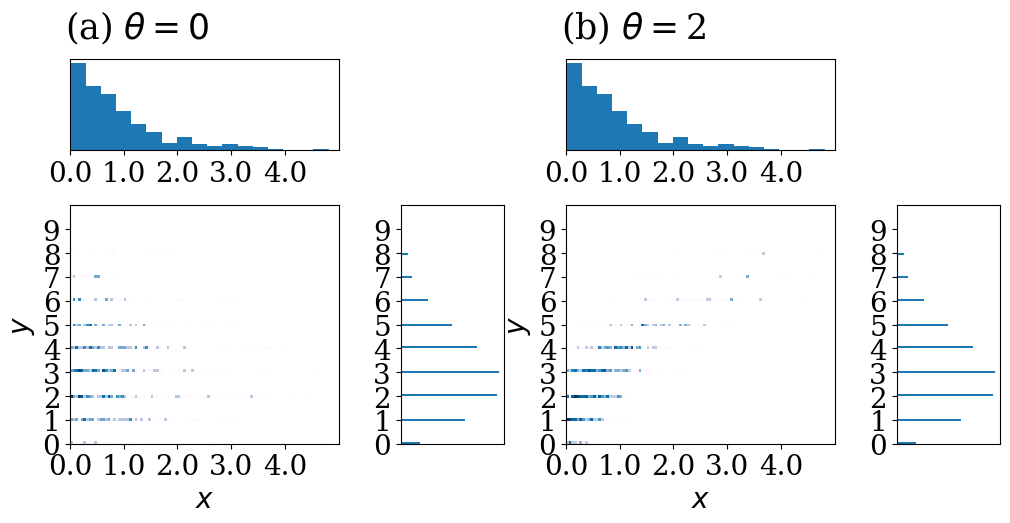

In [ ]:
fig = plt.figure(figsize=(12,5))
gs = matplotlib.gridspec.GridSpec(3, 6,wspace=0.6,hspace=0.6)
ax_main_1 = plt.subplot(gs[1:3, :2])
ax_xDist_1 = plt.subplot(gs[0, :2],sharex=ax_main_1)
ax_yDist_1 = plt.subplot(gs[1:3, 2],sharey=ax_main_1)

ax_main_2 = plt.subplot(gs[1:3, 3:5])
ax_xDist_2 = plt.subplot(gs[0, 3:5],sharex=ax_main_2)
ax_yDist_2= plt.subplot(gs[1:3, 5],sharey=ax_main_2)


ax_main_1.hist2d(X,Y,bins=100,range=[[0, 5], [0, 12]],norm=matplotlib.colors.LogNorm(),cmap="PuBu")
ax_main_1.set_xlabel("$x$",fontsize=20)
ax_main_1.set_ylabel("$y$",fontsize=20)
ax_main_1.set_xlim([0,5])
ax_main_1.set_ylim([0,10])
ax_main_1.set_xticks([1.*i for i in range(5)])
ax_main_1.set_xticklabels([round(1.*i,2) for i in range(5)],fontsize=20)
ax_main_1.set_yticks([i for i in range(10)])
ax_main_1.set_yticklabels([round(i,2) for i in range(10)],fontsize=20)
ax_main_1.text(-0.1,17,"(a) $\\theta=0$",fontsize=25)

ax_xDist_1.hist(X,bins=20,align='mid')
ax_xDist_1.set(ylabel='')
ax_xDist_1.set_yticks([])
ax_xDist_1.set_xticklabels([round(1.*i,2) for i in range(5)],fontsize=20)

ax_yDist_1.hist(Y,bins=100,orientation='horizontal',align='mid')
ax_yDist_1.set(xlabel='')
ax_yDist_1.set_xticks([])
ax_yDist_1.set_yticklabels([round(i,2) for i in range(10)],fontsize=20)


ax_main_2.hist2d(np.array(outputlist[-1])[:,0],np.array(outputlist[-1])[:,1],bins=100,range=[[0, 5], [0, 12]],norm=matplotlib.colors.LogNorm(),cmap="PuBu")
ax_main_2.set_xlabel("$x$",fontsize=20)
ax_main_2.set_ylabel("$y$",fontsize=20)
ax_main_2.set_xlim([0,5])
ax_main_2.set_ylim([0,10])
ax_main_2.set_xticks([1.*i for i in range(5)])
ax_main_2.set_xticklabels([round(1.*i,2) for i in range(5)],fontsize=20)
ax_main_2.set_yticks([i for i in range(10)])
ax_main_2.set_yticklabels([round(i,2) for i in range(10)],fontsize=20)
ax_main_2.text(-0.1,17,"(b) $\\theta=$"+str(target_th),fontsize=25)

ax_xDist_2.hist(X,bins=20,align='mid')
ax_xDist_2.set(ylabel='')
ax_xDist_2.set_yticks([])
ax_xDist_2.set_xticklabels([round(1.*i,2) for i in range(5)],fontsize=20)

ax_yDist_2.hist(Y,bins=100,orientation='horizontal',align='mid')
ax_yDist_2.set(xlabel='')
ax_yDist_2.set_xticks([])
ax_yDist_2.set_yticklabels([round(i,2) for i in range(10)],fontsize=20)

In [ ]:
if n < 501:
  # Full-batch path: feasible for small n. Provides a high-accuracy reference baseline.
  t0 = time.perf_counter()
  ex1_2_PLE_fullbatch = mininfo.min_info_Besag_fullbatch(
      X=outputlist[-1],
      h=h_cpc,
      tol=1e-5,        # Practical trade-off between accuracy and runtime
      max_iter=10_000, # Conservative iteration cap for stability
      sparseop=False
  )
  ex1_2_PLE_asymptoticCov_fullbatch = mininfo.min_info_Besag_asymptoticCovariance_fullbatch(
      X=outputlist[-1],
      h=h_cpc,
      theta_PLE=ex1_2_PLE_fullbatch  # Use the current full-batch estimate
  )
  t1_est = time.perf_counter()
  time_fullbatch = t1_est - t0
  print(f"Fullbatch without bootstrap: Finished in {t1_est - t0:0.4f} seconds")
  ex1_2_boot_PLE_fullbatch, ex1_2_bootm_PLE_fullbatch, ex1_2_bootcov_PLE_fullbatch = \
      mininfo.min_info_Besag_bootstrap_fullbatch(
          X=outputlist[-1],
          h=h_cpc,
          tol=1e-5,
          max_iter=10_000,
          B=50,
          sparseop=False
      )
  t1 = time.perf_counter()
  time_fullbatch_total = t1 - t0
  print(f"Fullbatch with bootstrap: Finished in {t1 - t0:0.4f} seconds")

  # Mini-batch with Adam only:
  # Rationale: fast initial progress via adaptive steps; acceptable if final variance is slightly higher.
  t0_Adam = time.perf_counter()
  ex1_2_PLE_Adam = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cpc,
      use_adam=True,
      use_rpj=False
  )[0]
  ex1_2_PLE_Adam_asymptoticCov = mininfo.min_info_Besag_asymptoticCovariance_minibatch(
      X=outputlist[-1],
      h=h_cpc,
      theta_PLE=ex1_2_PLE_Adam,
      RPJ_count=np.inf,
      num_s=None,
      num_t_per_s=10,
      num_pairs_J=100,
      seed=None
  )
  t1_est_Adam = time.perf_counter()
  time_Adam = t1_est_Adam - t0_Adam
  print(f"Minibatch (Adam) without bootstrap: Finished in {time_Adam:0.4f} seconds")
  ex1_2_boot_PLE_Adam, ex1_2_bootm_PLE_Adam, ex1_2_bootcov_PLE_Adam = \
      mininfo.min_info_Besag_bootstrap_SGD_Multicore(
          X=outputlist[-1],
          h=h_cpc,
          B=50,
          n_jobs=-1,
          progress=False,
          use_adam=True,
          use_rpj=False
      )
  t1_Adam = time.perf_counter()
  time_Adam_total = t1_Adam - t0_Adam
  print(f"Minibatch (Adam) with bootstrap: Finished in {time_Adam_total:0.4f} seconds")

  # Recommended two-stage mini-batch:
  # Step 1) Warm start with Adam (no RPJ) to quickly reach a good basin.
  # Step 2) Switch to plain SGD + RPJ averaging to reduce variance and stabilize the final estimate.
  t0_SGD = time.perf_counter()
  ex1_2_PLE_pre = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cpc,
      use_adam=True,
      use_rpj=False,
      verbose_every=0
  )[0]
  ex1_2_PLE_SGD, RPJcount_ex1_2_PLE_SGD = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cpc,
      init=ex1_2_PLE_pre,
      use_adam=False,
      use_rpj=True
  )
  ex1_2_PLE_SGD_asymptoticCov = mininfo.min_info_Besag_asymptoticCovariance_minibatch(
      X=outputlist[-1],
      h=h_cpc,
      theta_PLE=ex1_2_PLE_SGD,
      RPJ_count=RPJcount_ex1_2_PLE_SGD,
      num_s=None,
      num_t_per_s=10,
      num_pairs_J=100,
      seed=None
  )
  t1_est_SGD = time.perf_counter()
  time_SGD = t1_est_SGD - t0_SGD
  print(f"Minibatch (Adam+RPJ) without bootstrap: Finished in {time_SGD:0.4f} seconds")
  ex1_2_boot_PLE_SGD, ex1_2_bootm_PLE_SGD, ex1_2_bootcov_PLE_SGD = \
      mininfo.min_info_Besag_bootstrap_SGD_Multicore(
          X=outputlist[-1],
          h=h_cpc,
          B=50,
          n_jobs=-1,
          progress=False
      )
  t1_SGD = time.perf_counter()
  time_SGD_total = t1_SGD - t0_SGD
  print(f"Minibatch (Adam+RPJ) with bootstrap: Finished in {time_SGD_total:0.4f} seconds")

else:
  # Large-n path: skip full-batch due to computational cost, use only mini-batch methods.
  ex1_2_PLE_Adam = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cpc,
      use_adam=True,
      use_rpj=False
  )[0]
  ex1_2_PLE_SGD, RPJcount_ex1_2_PLE_SGD = mininfo.min_info_Besag_SGD(
      X=outputlist[-1],
      h=h_cpc,init=ex1_2_PLE_Adam,
      use_adam=False,
      use_rpj=True
  )
  ex1_2_PLE_SGD_asymptoticCov = mininfo.min_info_Besag_asymptoticCovariance_minibatch(
      X=outputlist[-1],
      h=h_cpc,
      theta_PLE=ex1_2_PLE_SGD,
      RPJ_count=RPJcount_ex1_2_PLE_SGD,
      num_s=None,
      num_t_per_s=10,
      num_pairs_J=100,
      seed=None
  )
  ex1_2_boot_PLE_SGD, ex1_2_bootm_PLE_SGD, ex1_2_bootcov_PLE_SGD = \
      mininfo.min_info_Besag_bootstrap_SGD_Multicore(
          X=outputlist[-1],
          h=h_cpc,
          B=100,        # Larger bootstrap count for more stable variance estimation
          n_jobs=-1,
          progress=False
      )

Fullbatch without bootstrap: Finished in 9.5786 seconds
Fullbatch with bootstrap: Finished in 73.5843 seconds
Minibatch (Adam) without bootstrap: Finished in 0.9064 seconds
Minibatch (Adam) with bootstrap: Finished in 10.0453 seconds
Minibatch (Adam+RPJ) without bootstrap: Finished in 1.6062 seconds
Minibatch (Adam+RPJ) with bootstrap: Finished in 10.9384 seconds


In [ ]:
if n<501:
  target_val = np.round(target_th[0], 3) if np.ndim(target_th) > 0 else np.round(float(target_th), 3)
  # Point estimates (parameter values)
  fb_ple = np.round(ex1_2_PLE_fullbatch[0], 3)
  mb_adam = np.round(ex1_2_PLE_Adam[0], 3)
  mb_sgd = np.round(ex1_2_PLE_SGD[0], 3)

  # Standard deviations
  fb_boot_sd = np.round(np.sqrt(ex1_2_bootcov_PLE_fullbatch[0, 0]), 3)
  mb_boot_sd = np.round(np.sqrt(ex1_2_bootcov_PLE_SGD), 3)
  mb_adam_boot_sd = np.round(np.sqrt(ex1_2_bootcov_PLE_Adam), 3)
  fb_asym_sd = np.round(np.sqrt(ex1_2_PLE_asymptoticCov_fullbatch[0, 0]), 3)
  mb_asym_sd = np.round(np.sqrt(ex1_2_PLE_SGD_asymptoticCov[0, 0]), 3)
  mb_adam_asym_sd = np.round(np.sqrt(ex1_2_PLE_Adam_asymptoticCov[0, 0]), 3)

  # Assemble the table; Target column has no sd -> set to NaN
  df = pd.DataFrame(
      {
          "Target":          [target_val,         np.nan,     np.nan, np.nan, np.nan],
          "Fullbatch":  [fb_ple,             fb_boot_sd, fb_asym_sd, time_fullbatch, time_fullbatch_total],
          "Minibatch (Adam)":  [mb_adam,             mb_adam_boot_sd, mb_adam_asym_sd, time_Adam,time_Adam_total],
          "Minibatch (Adam+RPJ)":  [mb_sgd,             mb_boot_sd, mb_asym_sd, time_SGD, time_SGD_total],
      },
      index=["Value", "Bootstrap sd", "Asymptotic sd", "Initial time","Total time"]
  )
  print(df)
  print("Note that for SGD with only Adam, there is no theoretical support on the use of asympotic sd and the asymptotic sd does not work well")
else:
  print("Target theta  : "+str(target_th))
  print("Minibatch PLE : "+str(np.round(ex1_2_PLE_SGD[0],3)))
  print("Bootstrap  sd : "+str(np.round(np.sqrt(ex1_2_bootcov_PLE_SGD),3)))
  print("Asymptotic sd : "+str(np.round(np.sqrt(ex1_2_PLE_SGD_asymptoticCov[0,0]),3)))

               Target  Fullbatch  Minibatch (Adam)  Minibatch (Adam+RPJ)
Value             2.0   1.951000          1.907000              1.875000
Bootstrap sd      NaN   0.145000          0.642000              0.190000
Asymptotic sd     NaN   0.149000          0.111000              0.097000
Initial time      NaN   9.578618          0.906405              1.606222
Total time        NaN  73.584318         10.045276             10.938352
Note that for SGD with only Adam, there is no theoretical support on the use of asympotic sd and the asymptotic sd does not work well


#Example 2: Penguins data (Mixed graphical model with three-dimensional interactions)

In [ ]:
from palmerpenguins import load_penguins
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

penguins = load_penguins()
penguins.head()
df = penguins.copy()
df.dropna(how='any')
processed_df=df[df["species"]=="Adelie"].drop(['species','island','year'], axis=1).dropna(how='any')
##Preprocessing
scaling_columns = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
sc = StandardScaler().fit(processed_df[scaling_columns])

# standardization
scaled_df = pd.DataFrame(sc.transform(processed_df[scaling_columns]), columns=scaling_columns, index=processed_df.index)
processed_df.update(scaled_df)
# One hot encoding
processed_df["sex"] = processed_df["sex"].map({"male": 1, "female": 0})

list_penguins = processed_df.values.tolist()

In [ ]:
def h_penguins_all_3factor(x):
  h_list = []
  for i in range(5):
    for j in [ k for k in range(5) if (k>i)]:
       h_list.append(x[i]*x[j])
  for i in range(5):
    for j in [ k for k in range(5) if (k>i)]:
      for k in [kk for kk in range(5) if (kk>j)]:
        h_list.append(x[i]*x[j]*x[k])
  return np.array(h_list)

Analysis with Three factor model

In [ ]:
M_iter = 10000
Burnin_RPJ = 5000
t0 = time.perf_counter()
ex2_all_3factor_PLE_fullbatch = mininfo.min_info_Besag_fullbatch(X=list_penguins,h=h_penguins_all_3factor,max_iter=M_iter,tol=10**(-5))
ex2_all_3factor_asymptoticCov_PLE_fullbatch=mininfo.min_info_Besag_asymptoticCovariance_fullbatch(X=list_penguins,
                                                                                                  h=h_penguins_all_3factor,
                                                                                                  theta_PLE=ex2_all_3factor_PLE_fullbatch)
ex2_all_3factor_boot_PLE_fullbatch,ex2_all_3factor_bootm_PLE_fullbatch,ex2_all_3factor_bootcov_PLE_fullbatch=mininfo.min_info_Besag_bootstrap_fullbatch(X=list_penguins,
                                                                                                                                                h=h_penguins_all_3factor,tol=10**(-5),
                                                                                                                                                max_iter=M_iter,B=100,sparseop=False)
t1 = time.perf_counter()
print(f"Fullbatch: Finished in {t1 - t0:0.4f} seconds")
t0 = time.perf_counter()
ex2_all_3factor_PLE_minibatch_pre = mininfo.min_info_Besag_SGD(X=list_penguins,h=h_penguins_all_3factor,max_iter=M_iter,use_adam=True,use_rpj=False)[0]
ex2_all_3factor_PLE_minibatch,RPJcount_ex2_all_3factor = mininfo.min_info_Besag_SGD(X=list_penguins,h=h_penguins_all_3factor,max_iter= M_iter,avg_start=Burnin_RPJ,
                                                                           init=ex2_all_3factor_PLE_minibatch_pre,use_adam=False)
ex2_all_3factor_asymptoticCov_PLE_minibatch=mininfo.min_info_Besag_asymptoticCovariance_minibatch(X=list_penguins,h=h_penguins_all_3factor,
                                                                                  theta_PLE=ex2_all_3factor_PLE_minibatch,
                                                                                  RPJ_count=RPJcount_ex2_all_3factor,
                                                                                  num_s=len(list_penguins),
                                                                                  num_t_per_s=100,
                                                                                  num_pairs_J=1000,seed=None)
ex2_all_3factor_boot_PLE_minibatch,ex2_all_3factor_bootm_PLE_minibatch,ex2_all_3factor_bootcov_PLE_minibatch = mininfo.min_info_Besag_bootstrap_SGD_Multicore(X=list_penguins,
                                                                                              h=h_penguins_all_3factor, max_iter= M_iter,B=2,
                                                                                              n_jobs=-1, progress=False,
                                                                                              avg_start=Burnin_RPJ)


t1 = time.perf_counter()
print(f"Minibatch: Finished in {t1 - t0:0.4f} seconds")

Fullbatch: Finished in 181.2959 seconds
Minibatch: Finished in 6.4479 seconds


In [ ]:
edges_3factors = []
for i in range(5):
  for j in [ k for k in range(5) if (k>i)]:
      edges_3factors.append(str(i+1)+"-"+str(j+1)+"  ")
for i in range(5):
  for j in [ k for k in range(5) if (k>i)]:
    for k in [kk for kk in range(5) if (kk>j)]:
      edges_3factors.append(str(i+1)+"-"+str(j+1)+"-"+str(k+1))

k = len(edges_3factors)

# Extract and round values (first k entries assumed to correspond to the edges above)
ple_3factor_fb  = np.asarray(ex2_all_3factor_PLE_fullbatch)[:k]
ple_3factor_mb  = np.asarray(ex2_all_3factor_PLE_minibatch)[:k]

sd_asym_3factor_fb = np.sqrt(np.diag(ex2_all_3factor_asymptoticCov_PLE_fullbatch))[:k]
sd_asym_3factor_mb = np.sqrt(np.diag(ex2_all_3factor_asymptoticCov_PLE_minibatch))[:k]

sd_boot_3factor_fb = np.sqrt(np.diag(ex2_all_3factor_bootcov_PLE_fullbatch))[:k]
sd_boot_3factor_mb = np.sqrt(np.diag(ex2_all_3factor_bootcov_PLE_minibatch))[:k]

# Assemble the table
df = pd.DataFrame(
    {
        "PLE (fb)":           np.round(ple_3factor_fb,3),
        "PLE (mb)":           np.round(ple_3factor_mb,3),
        "Asymptotic sd (fb)":  np.round(sd_asym_3factor_fb,3),
        "Asymptotic sd (mb)":  np.round(sd_asym_3factor_mb,3),
        "Bootstrap sd (fb)":   np.round(sd_boot_3factor_fb,3),
        "Bootstrap sd (mb)":   np.round(sd_boot_3factor_mb,3),
    },
    index=edges_3factors
)

print("\nEdge-wise summary (rounded to 3 decimals):")
print("fb:fullbatch, \nmb:minibatch")
print(df.to_string())


Edge-wise summary (rounded to 3 decimals):
fb:fullbatch, 
mb:minibatch
       PLE (fb)  PLE (mb)  Asymptotic sd (fb)  Asymptotic sd (mb)  Bootstrap sd (fb)  Bootstrap sd (mb)
1-2       0.100     0.446               0.253               0.152              0.306              0.120
1-3      -0.374    -0.620               0.233               0.121              0.269              0.272
1-4       0.405     0.518               0.318               0.205              0.328              0.149
1-5       1.840     3.501               0.400               0.200              0.443              0.895
2-3      -0.315    -0.075               0.227               0.157              0.281              0.122
2-4       1.156     1.681               0.328               0.183              0.462              0.102
2-5       1.414     1.762               0.409               0.255              0.598              0.185
3-4       0.490     0.463               0.296               0.191              0.326            

In [ ]:
#Edge ranking
#Comparison using Normalized score
rankingscore_3factor_fb_asym  = np.abs(ple_3factor_fb) / sd_asym_3factor_fb       # baseline for ranking (fb/asym)
rankingscore_3factor_mb_asym  = np.abs(ple_3factor_mb) / sd_asym_3factor_mb       # compare 1: mb/asym
rankingscore_3factor_fb_boot  = np.abs(ple_3factor_fb) / sd_boot_3factor_fb       # compare 2: fb/boot
rankingscore_3factor_mb_boot  = np.abs(ple_3factor_mb) / sd_boot_3factor_mb       # compare 3: mb/boot

rank_3factor_fb_asym = to_ranks_desc(rankingscore_3factor_fb_asym)
rank_3factor_mb_asym = to_ranks_desc(rankingscore_3factor_mb_asym)
rank_3factor_fb_boot = to_ranks_desc(rankingscore_3factor_fb_boot)
rank_3factor_mb_boot = to_ranks_desc(rankingscore_3factor_mb_boot)

gap_3factor_mb_asym = np.abs(rank_3factor_mb_asym - rank_3factor_fb_asym)
gap_3factor_fb_boot = np.abs(rank_3factor_fb_boot - rank_3factor_fb_asym)
gap_3factor_mb_boot = np.abs(rank_3factor_mb_boot - rank_3factor_fb_asym)


#Comparison using Absolute score
rankingscore_3factor_fb = np.abs(ple_3factor_fb)
rankingscore_3factor_mb = np.abs(ple_3factor_mb)

rank_3factor_fb = to_ranks_desc(rankingscore_3factor_fb)
rank_3factor_mb = to_ranks_desc(rankingscore_3factor_mb)

gap_3factor_fb = np.abs(rank_3factor_fb - rank_3factor_fb)
gap_3factor_mb = np.abs(rank_3factor_mb - rank_3factor_fb)

Text(0.5, 1.0, 'Rank–rank: mb/boot vs fb/asym')

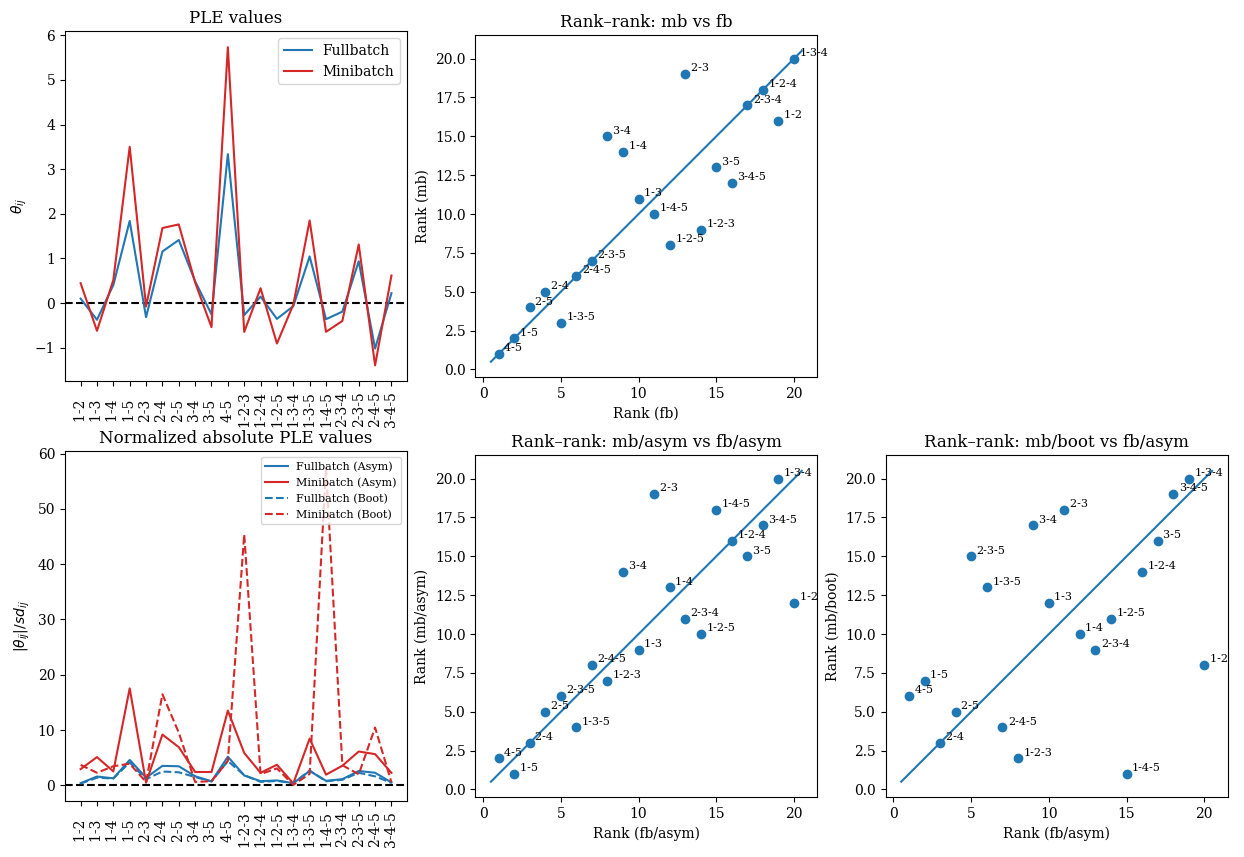

In [ ]:
fig = plt.figure(figsize=(15,10))
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)
ax6 = fig.add_subplot(236)

ax1.set_title("PLE values")
ax1.axhline(y=0, color='k', linestyle='--')
ax1.plot(edges_3factors,ple_3factor_fb, color="tab:blue",label="Fullbatch")
ax1.plot(edges_3factors,ple_3factor_mb, color="tab:red",label="Minibatch")
ax1.legend()
ax1.set_ylabel(r"$\theta_{ij}$")
ax1.tick_params(axis='x', rotation=90)



ax2.scatter(rank_3factor_fb, rank_3factor_mb)
ax2.set_aspect("equal")
lo, hi = 0.5, len(rank_3factor_fb) + 0.5
ax2.plot([lo, hi], [lo, hi])  # y=x reference line
for i, e in enumerate(edges_3factors):
    ax2.annotate(e, (rank_3factor_fb[i], rank_3factor_mb[i]), xytext=(4, 2),
                 textcoords="offset points", fontsize=8)
ax2.set_xlabel("Rank (fb)")
ax2.set_ylabel("Rank (mb)")
ax2.set_title("Rank–rank: mb vs fb")


ax4.set_title("Normalized absolute PLE values")
ax4.axhline(y=0, color='k', linestyle='--')

ax4.plot(edges_3factors, abs(ple_3factor_fb)/sd_asym_3factor_fb, color="tab:blue",label="Fullbatch (Asym)")
ax4.plot(edges_3factors, abs(ple_3factor_mb)/sd_asym_3factor_mb, color="tab:red",label="Minibatch (Asym)")
ax4.plot(edges_3factors, abs(ple_3factor_fb)/sd_boot_3factor_fb, color="tab:blue",linestyle="dashed",label="Fullbatch (Boot)")
ax4.plot(edges_3factors, abs(ple_3factor_mb)/sd_boot_3factor_mb, color="tab:red",linestyle="dashed",label="Minibatch (Boot)")
ax4.set_ylabel(r"$|\theta_{ij}|/sd_{ij}$")
ax4.tick_params(axis='x', rotation=90)
ax4.legend(loc="upper right",fontsize=8)

ax5.scatter(rank_3factor_fb_asym, rank_3factor_mb_asym)
ax5.set_aspect("equal")
lo, hi = 0.5, len(rank_3factor_fb_asym) + 0.5
ax5.plot([lo, hi], [lo, hi])  # y=x reference line
for i, e in enumerate(edges_3factors):
    ax5.annotate(e, (rank_3factor_fb_asym[i], rank_3factor_mb_asym[i]), xytext=(4, 2),
                 textcoords="offset points", fontsize=8)
ax5.set_xlabel("Rank (fb/asym)")
ax5.set_ylabel("Rank (mb/asym)")
ax5.set_title("Rank–rank: mb/asym vs fb/asym")


ax6.scatter(rank_3factor_fb_asym, rank_3factor_mb_boot)
ax6.set_aspect("equal")
lo, hi = 0.5, len(rank_3factor_fb_asym) + 0.5
ax6.plot([lo, hi], [lo, hi])  # y=x reference line
for i, e in enumerate(edges_3factors):
    ax6.annotate(e, (rank_3factor_fb_asym[i], rank_3factor_mb_boot[i]), xytext=(4, 2),
                 textcoords="offset points", fontsize=8)
ax6.set_xlabel("Rank (fb/asym)")
ax6.set_ylabel("Rank (mb/boot)")
ax6.set_title("Rank–rank: mb/boot vs fb/asym")

#Example 3: Earthquake catalog data (orthogonal frame data and real valued data)

- We analyze the dependence between mechanism solution and depth in the earthquake catalog
- We use the 158 earthquake data that occurred in Japan during the period from January 1st, 2021 to December 8th, 2021
- The data we use are provided by the Japan Meteorological Agency and contain
the information about (0) time (1) latitude (2) longitude (3) depth (4) Magnitude (5) JMA Magnitude (6) strike 1 (7) dip 1 (8) slip 1 (9) strike 2 (10) dip 2 (11) slip 2 of the events
- We use the columns of (3) depth ,(6)-(11) mechanism solution
- The mechanism solution of an earthquake event is given in the form of two orthogonal axes in the 3D space (Arnold and Jupp, 2013): $\{v_P,v_T\in \mathbb{R}^{3}: (v_P)^{\top}v_T=0, \|v_P\|=1, \|v_T\|=1\}$
- To analyze the dependence between mechanism solution and depth, we consider the minimum information dependence model with the form
$\exp(\mathrm{tr}(A(z v_{P}v_{P}^{\top})) + \mathrm{tr}(B(z v_{T}v_{T}^{\top})) +\text{terms related to marginals})$, where $z$ is the depth.

###References
- JAPAN METEOROLOGICAL AGENCY (2022). The seismological bulletin of Japan. https://www.data.jma.go.jp/svd/eqev/data/bulletin/index_e.html.
- R. Arnold and P. Jupp (2013). Statistics of orthogonal axial frames. Biometrika 100 571–586.

In [ ]:
Mechsol_df=pd.read_csv(your_workingdir+'Mechsol_format.csv')

#Preprocessing of lat / lon/ depth

Mechsol_df["latitude"]=np.array([np.round(float(Mechsol_df["latitude"][i].split(":")[0])+float(Mechsol_df["latitude"][i].split(":")[1])/60,3) for i in range(Mechsol_df.shape[0])])
Mechsol_df["longitude"]=np.array([np.round(float(Mechsol_df["longitude"][i].split(":")[0])+float(Mechsol_df["longitude"][i].split(":")[1])/60,3) for i in range(Mechsol_df.shape[0])])
Mechsol_df["depth"]=np.array([float(Mechsol_df["depth"][i][:-2]) for i in range(Mechsol_df.shape[0]) ])

#Standardization of depth

from sklearn.preprocessing import StandardScaler
scaling_columns = ["depth"]
sc = StandardScaler().fit(Mechsol_df[scaling_columns])
scaled_df = pd.DataFrame(sc.transform(Mechsol_df[scaling_columns]), columns=scaling_columns, index=Mechsol_df.index)
Mechsol_df.update(scaled_df)

In [ ]:
#Converting strike/dip/slip into a vector
#Reference: https://www.data.jma.go.jp/svd/eqev/data/mech/kaisetu/mechkaisetu2.html

def angle2vec(strike,dip,slip):
  phi   = strike * (2*np.pi) / 360
  delta = dip    * (2*np.pi) / 360
  lam   = slip   * (2*np.pi) / 360
  ####
  v1    = np.cos(lam)*np.cos(phi) + np.sin(lam)*np.cos(delta)*np.sin(phi)
  v2    = np.cos(lam)*np.sin(phi) - np.sin(lam)*np.cos(delta)*np.cos(phi)
  v3    = -np.sin(lam)*np.sin(delta)
  v     = np.array([v1,v2,v3])
  return v.T


#Orthogonalization
#vec 1 and vec 2 are nearly orthogonal but not exactly orthogonal; so we orthogonalize these in the following step.

vec1       =angle2vec(Mechsol_df["strike1"], Mechsol_df["dip1"], Mechsol_df["slip1"])
vec2       =angle2vec(Mechsol_df["strike2"], Mechsol_df["dip2"], Mechsol_df["slip2"])
vec2_ortho = vec2-(np.diag((np.diag(vec1.dot(vec2.T))/np.diag(vec1.dot(vec1.T)))).dot(vec1))
vec2       = np.diag(1/np.sqrt(np.diag(vec2_ortho.dot(vec2_ortho.T)))).dot(vec2_ortho)

#Calculate N-axis, the cross product of vec1 and vec2
vec3 = np.cross(vec1 , vec2, axisc=1)
vec3 = np.diag(1/np.sqrt(np.diag(vec3.dot(vec3.T)))).dot(vec3)


#Store P-axis/T-axis/N-axis
Mechsol_df["P-axis P1"] = (vec1-vec2)[:,0]/np.sqrt(2)
Mechsol_df["P-axis P2"] = (vec1-vec2)[:,1]/np.sqrt(2)
Mechsol_df["P-axis P3"] = (vec1-vec2)[:,2]/np.sqrt(2)

Mechsol_df["T-axis T1"] = (vec1+vec2)[:,0]/np.sqrt(2)
Mechsol_df["T-axis T2"] = (vec1+vec2)[:,1]/np.sqrt(2)
Mechsol_df["T-axis T3"] = (vec1+vec2)[:,2]/np.sqrt(2)

Mechsol_df["N-axis N1"] = vec3[:,0]
Mechsol_df["N-axis N2"] = vec3[:,1]
Mechsol_df["N-axis N3"] = vec3[:,2]

In [ ]:
selected_columns=["depth","P-axis P1","P-axis P2","P-axis P3","T-axis T1","T-axis T2","T-axis T3","N-axis N1","N-axis N2","N-axis N3"]
list_mechsol= Mechsol_df[selected_columns].values.tolist()

In [ ]:
def h_mechsol(x):
  #x[0]: depth
  #x[1],x[2],x[3]: P-axis
  #x[4],x[5],x[6]: T-axis
  #x[7],x[8],x[9]: N-axis
  hP_11 = x[0] * x[1] * x[1]
  hP_12 = x[0] * x[1] * x[2]
  hP_13 = x[0] * x[1] * x[3]
  hP_22 = x[0] * x[2] * x[2]
  hP_23 = x[0] * x[2] * x[3]
  hT_11 = x[0] * x[4] * x[4]
  hT_12 = x[0] * x[4] * x[5]
  hT_13 = x[0] * x[4] * x[6]
  hT_22 = x[0] * x[5] * x[5]
  hT_23 = x[0] * x[5] * x[6]
  return np.array([hP_11,hP_12,hP_13,hP_22,hP_23, hT_11,hT_12,hT_13,hT_22,hT_23])

In [ ]:
t0_fullbatch = time.perf_counter()
ex3_PLE_fullbatch=mininfo.min_info_Besag_fullbatch(X=list_mechsol,h=h_mechsol,max_iter=10000,tol=10**(-5))
ex3_asymptoticCov_PLE_fullbatch=mininfo.min_info_Besag_asymptoticCovariance_fullbatch(X=list_mechsol,h=h_mechsol,theta_PLE=ex3_PLE_fullbatch)
ex3_boot_PLE_fullbatch,ex3_bootm_PLE_fullbatch,ex3_bootcov_PLE_fullbatch=mininfo.min_info_Besag_bootstrap_fullbatch(X=list_mechsol,h=h_mechsol,tol=10**(-5),max_iter=10000,B=100)
t1_fullbatch = time.perf_counter()
time_fullbatch = t1_fullbatch - t0_fullbatch
print(f"Fullbatch: Finished in {time_fullbatch:0.4f} seconds")
t0_SGD = time.perf_counter()
ex3_PLE_pre = mininfo.min_info_Besag_SGD(X=list_mechsol,h=h_mechsol,max_iter=10000,use_adam=True,use_rpj=False)[0]
ex3_PLE_SGD, ex3_RPJcount = mininfo.min_info_Besag_SGD(X=list_mechsol,h=h_mechsol,max_iter=10000,avg_start=5000,init=ex3_PLE_pre,use_adam=False,use_rpj=True)
ex3_asymptoticCov_PLE_SGD = mininfo.min_info_Besag_asymptoticCovariance_minibatch(X=list_mechsol,h=h_mechsol,theta_PLE=ex3_PLE_SGD,RPJ_count=ex3_RPJcount,
                                                                                  num_s=len(list_mechsol),
                                                                                  num_t_per_s=100,
                                                                                  num_pairs_J=1000,seed=None)
ex3_boot_PLE,ex3_bootm_PLE,ex3_bootcov_PLE = mininfo.min_info_Besag_bootstrap_SGD_Multicore(X=list_mechsol,h=h_mechsol,max_iter=10000,B=100,n_jobs=-1,progress=False,avg_start=5000)
t1_SGD = time.perf_counter()
time_SGD = t1_SGD - t0_SGD
print(f"SGD: Finished in {time_SGD:0.4f} seconds")

Fullbatch: Finished in 111.2863 seconds
SGD: Finished in 24.5961 seconds


In [ ]:
print(ex3_PLE_fullbatch)
print(ex3_PLE_SGD)

[-0.32851956  0.41905517  0.19468896 -0.57106099 -0.56852785  0.21281093
 -0.13002926  0.15425414  0.69368915 -0.18284498]
[-0.33275923  0.41107316  0.19130168 -0.7632714  -0.66233632  0.33937238
  0.14391605  0.29643168  0.7655238  -0.08252483]


In [ ]:

# interpretable representation
A_PLE = np.matrix(np.zeros(9)).reshape(3,3)  # compressional part
A_PLE[0,0] = ex3_PLE_fullbatch[0]
A_PLE[0,1] = ex3_PLE_fullbatch[1]
A_PLE[0,2] = ex3_PLE_fullbatch[2]
A_PLE[1,1] = ex3_PLE_fullbatch[3]
A_PLE[1,2] = ex3_PLE_fullbatch[4]
A_PLE = (A_PLE + A_PLE.T)/2
A_PLE_adjust  = A_PLE - linalg.eigvals(A_PLE)[1].real * np.diag([1,1,1])


##Uncertainty calculus based on bootstrap
A_U = []
v1_A_U  = []
v3_A_U  = []

for b in range(len(ex3_boot_PLE_fullbatch)):

  mid_matrix_A = np.matrix(np.zeros(9)).reshape(3,3)
  mid_matrix_A[0,0] = ex3_boot_PLE_fullbatch[b][0]
  mid_matrix_A[0,1] = ex3_boot_PLE_fullbatch[b][1]
  mid_matrix_A[0,2] = ex3_boot_PLE_fullbatch[b][2]
  mid_matrix_A[1,1] = ex3_boot_PLE_fullbatch[b][3]
  mid_matrix_A[1,2] = ex3_boot_PLE_fullbatch[b][4]
  mid_matrix_A = (mid_matrix_A + mid_matrix_A.T)/2
  mid_matrix_A_adjust  = mid_matrix_A - linalg.eigvals(mid_matrix_A)[1].real * np.diag([1,1,1])

  A_U.append(mid_matrix_A_adjust)
  if  (linalg.eigvals(mid_matrix_A_adjust)[0].real > linalg.eigvals(mid_matrix_A_adjust)[2].real) :
    v1_A_U.append( linalg.eig(mid_matrix_A_adjust )[1][:,0] )
    v3_A_U.append( linalg.eig(mid_matrix_A_adjust )[1][:,2] )
  else:
    v1_A_U.append( linalg.eig(mid_matrix_A_adjust )[1][:,2] )
    v3_A_U.append( linalg.eig(mid_matrix_A_adjust )[1][:,0] )

if linalg.eigvals(A_PLE_adjust)[0].real > linalg.eigvals(A_PLE_adjust)[2].real:
  v1 = linalg.eig(A_PLE_adjust)[1][:,0]
  v3 = linalg.eig(A_PLE_adjust)[1][:,2]
else:
  v1 = linalg.eig(A_PLE_adjust)[1][:,2]
  v3 = linalg.eig(A_PLE_adjust)[1][:,0]

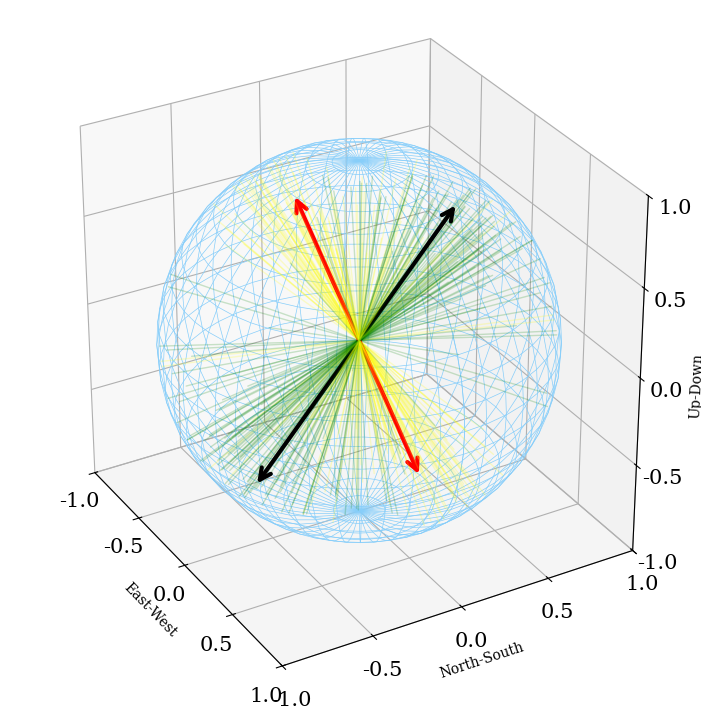

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

class Arrow3D(FancyArrowPatch):
    def __init__(self, start=[0,0,0], end=[1,1,1], *args, **kwargs):
        if "arrowstyle" not in kwargs:
            kwargs["arrowstyle"] = "-"
        if "mutation_scale" not in kwargs:
            kwargs["mutation_scale"] = 20
        if "color" not in kwargs:
            kwargs["color"] = "k"
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        xs = [start[0], end[0]]
        ys = [start[1], end[1]]
        zs = [start[2], end[2]]
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))

        return np.min(zs)


fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(111, projection='3d')
ax.set_box_aspect((1,1,1))

# sphere
u,v=np.mgrid[0:2*np.pi:50j, 0:np.pi:25j]
x=np.cos(u)*np.sin(v)
y=np.sin(u)*np.sin(v)
z=np.cos(v)
ax.plot_wireframe(x, y, z, color='lightskyblue', linewidth=0.5)
ax.set_xlim([-1,1])
ax.set_xticks([-1+0.5*i for i in range(5)])
ax.set_xticklabels([round(-1+0.5*i,2) for i in range(5)],fontsize=15)
ax.set_ylim([-1,1])
ax.set_yticks([-1+0.5*i for i in range(5)])
ax.set_yticklabels([round(-1+0.5*i,2) for i in range(5)],fontsize=15)
ax.set_zlim([-1,1])
ax.set_zticks([-1+0.5*i for i in range(5)])
ax.set_zticklabels([round(-1+0.5*i,2) for i in range(5)],fontsize=15)
ax.set_xlabel("East-West",fontsize=10)
ax.set_ylabel("North-South",fontsize=10)
ax.set_zlabel("Up-Down",fontsize=10)
ax.view_init(30, -30)
for i in range(100):
  start1 = [np.array(v1_A_U)[i,0],np.array(v1_A_U)[i,1],np.array(v1_A_U)[i,2]]
  start3 = [np.array(v3_A_U)[i,0],np.array(v3_A_U)[i,1],np.array(v3_A_U)[i,2]]
  ax.add_artist(Arrow3D(start=list(-np.array(start1)), end=list(start1),color="yellow",alpha=0.2))
  ax.add_artist(Arrow3D(start=list(-np.array(start3)), end=list(start3),color="green",alpha=0.2))

ax.add_artist(Arrow3D(start=list(-v1), end=list(v1),color="red",linewidth=3,arrowstyle="<->"))
ax.add_artist(Arrow3D(start=list(-v3), end=list(v3),color="black",linewidth=3,arrowstyle="<->"))
plt.subplots_adjust(left=0.1, right=1.2, bottom=0.1, top=0.95)
plt.show()